# Time Series Classification

In [1]:
import multipers as mp
from os.path import expanduser
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from gudhi.point_cloud.timedelay import TimeDelayEmbedding
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

This dataset can be found at https://www.timeseriesclassification.com/description.php?Dataset=Coffee

In [2]:
DATASET_PATH=expanduser("~/Datasets/UCR/")
dataset_path = DATASET_PATH + "Coffee/Coffee"
xtrain = np.array(pd.read_csv(dataset_path+"_TRAIN.tsv", delimiter='\t', header=None, index_col=None, engine='python'))
ytrain = LabelEncoder().fit_transform(xtrain[:,0])
xtrain = xtrain[:,1:]
xtest = np.array(pd.read_csv(dataset_path + "_TEST.tsv", delimiter='\t', header=None, index_col=None, engine='python'))
ytest = LabelEncoder().fit_transform(xtest[:,0])
xtest = xtest[:,1:]

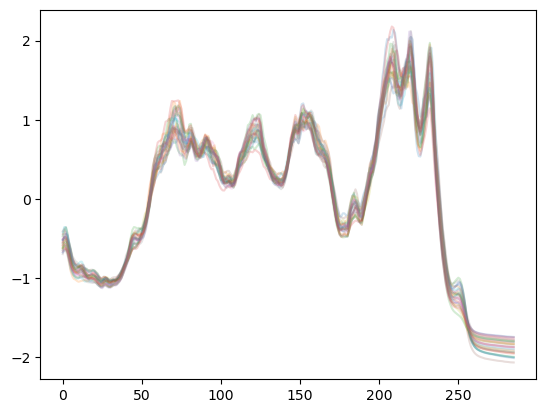

In [3]:
## the time-series of the Coffee dataset
plt.plot(xtrain.T, alpha=.2);

## Time Delay Embedding

In this format, time series are not very well suited for a topological analysis.

However, using Time Delay Embedding, which falls into the theory of 
[Taken's Theorem](https://en.wikipedia.org/wiki/Takens%27s_theorem)
we embed time series into a euclidian space, turning them into curves in a euclidian space.
<br>
The advantages of this approach is that this embedding doesn't depend on reparametrization of the time series,
and its construction doesn't depend on the number of sampling points.

Furthermore, if the parameters of this embedding are well chosen, the periodicity properties of the 
time series translates into topological properties of the embedding.

Using the usual [Rips-Density bifiltration](../filtrations/rips.ipynb) allows
to recover the topological properties (and thus some Fourier coefficient
information)
from the time series, as well as their importance (via the density parameter).

Of course, a bunch of reasonable (and faster) multi-filtrations can be used
instead of this one, e.g.,
[Function-Delaunay](../filtrations/function_delaunay.ipynb).

In [4]:
## Default parameters
dim=3
delay=1
skip=1
TDE = TimeDelayEmbedding(dim=dim, delay=delay, skip=skip)
xtrain = TDE.transform(xtrain)
xtest = TDE.transform(xtest)

In [5]:
np.asarray(xtrain).shape # num_time_series, embedding_curve_sampling, embedding_dimension

(28, 284, 3)

## Step by step

This is a point cloud now, so it can be dealt with with usual pipelines. 
<br>
Here each of entry of `xtrain` will be turned into two multi-simplextrees : 
 - Rips + (gaussian kernel density estimation with bandwith $0.1*\mathrm{scale}(\mathrm{xtrain})$)
 - Rips + (Distance to measure with mass threshold 0.1)

And we'll see which one gives the best results later.

In [7]:
import multipers.ml.filtered_complex as mmf
sts = mmf.PointCloud2FilteredComplex(bandwidths=[-.1], masses=[.1], complex="rips").fit_transform(xtrain)
sts = mmf.FilteredComplexPreprocess(num_collapses=-2, expand_dim=2).fit_transform(sts)
sts[0]

[SimplexTreeMulti[dtype=float64,num_param=2,kcritical=False,is_squeezed=False,max_dim=2],
 SimplexTreeMulti[dtype=float64,num_param=2,kcritical=False,is_squeezed=False,max_dim=2]]

We generate a [module approximation](../invariants/module_approximation.ipynb)
for each simplextree.

In [8]:
import multipers.ml.mma as mma
mods = mma.FilteredComplex2MMA().fit_transform(sts)

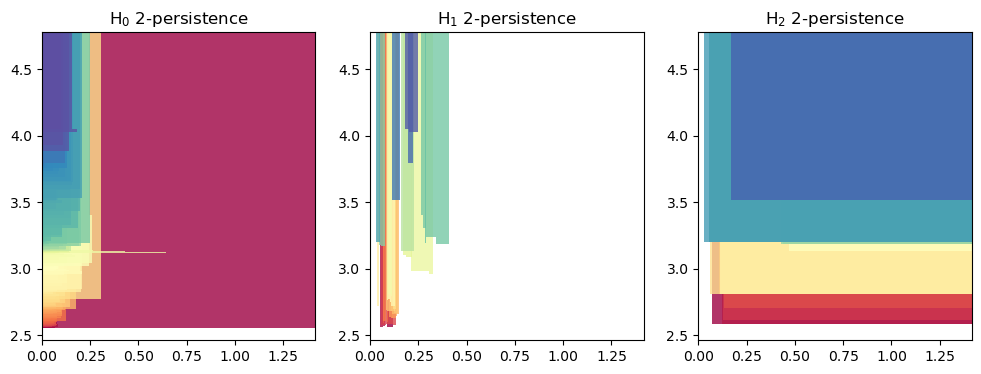

In [9]:
mods[0][0].plot()

Normalize the filtration values

In [10]:
mods = mma.MMAFormatter(normalize=True).fit_transform(mods)

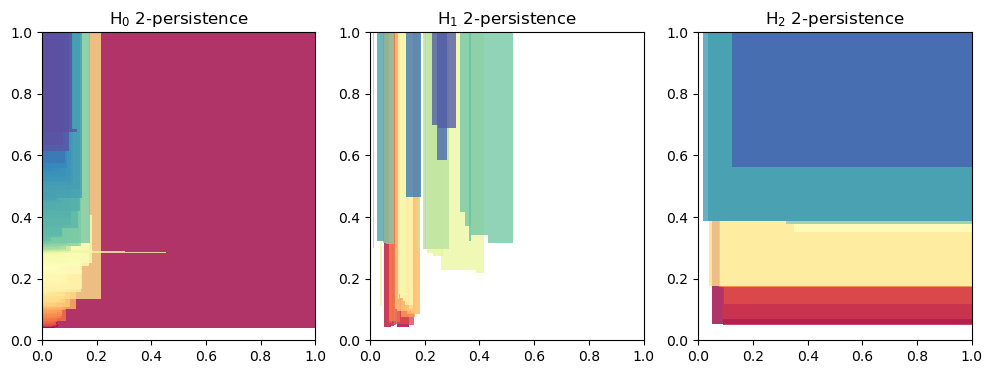

In [11]:
mod = mods[0][0]
mod.plot()

We can then turn these into vectors:

In [12]:
to_img = mma.MMA2IMG(bandwidth=.1, degrees = [0,1], n_jobs = 1, resolution=50, kernel = "gaussian", flatten=False, signed=True).fit(mods)
imgs = to_img.transform(mods)

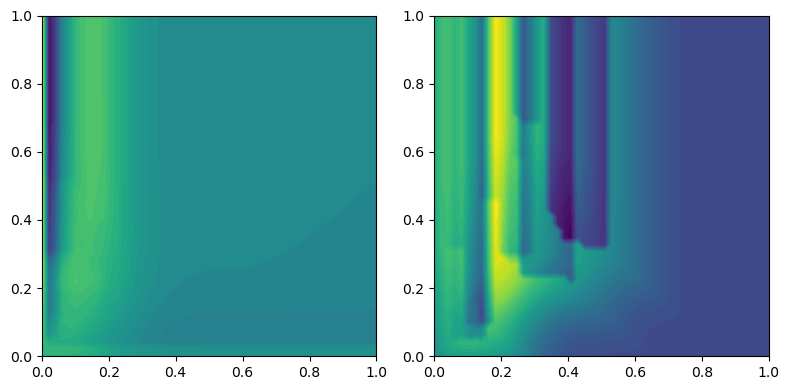

In [13]:
from multipers.plots import plot_surfaces
plot_surfaces(([np.linspace(0,1,50)]*2, imgs[0][0]), cmap="viridis")

And classify all of this using, e.g., a Random Forest Classifier. 

## Full pipeline

**Note.** Although normalization allow for reasonable parameter selection without prior knowledge, 
it is **very** recommended to cross-validate the parameters using, e.g., scikit-learn's GridSearchCV,
to significantly increase the performances.

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [18]:
## We wrap up everything into this pipeline
pipeline = Pipeline([
    ("st", mmp.PointCloud2FilteredComplex(bandwidths=[-.2], masses=[.1], complex="delaunay")),
    ("preprocess", mmp.FilteredComplexPreprocess(reduce_degrees=[0,1])),
    ("mod", mma.FilteredComplex2MMA(n_jobs=-1)),
    ("normalization", mma.MMAFormatter(normalize=True)),
    ("vectorization", mma.MMA2IMG(bandwidth=.1, degrees = [0,1], n_jobs = -1, resolution=50, kernel = "gaussian", flatten=True)),
    ("classifier", RandomForestClassifier()),
])

In [19]:
# Train step
pipeline.fit(xtrain,ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('st', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,bandwidths,[-0.2]
,masses,[0.1]
,knns,[]
,threshold,None
,complex,'delaunay'
,node_degrees,None
,core_degrees,None


In [20]:
# Test score
pipeline.score(xtest,ytest)

0.9642857142857143